In [1]:
import math

math.sqrt(16)

4.0

In [ ]:

# ==========================================
# 3. Pré-cálculo dos Coeficientes
# ==========================================
def calcula_cn(n, L):
    return (1.0 / n) * (L**2/(n * np.pi)) * (-1) ** n-1

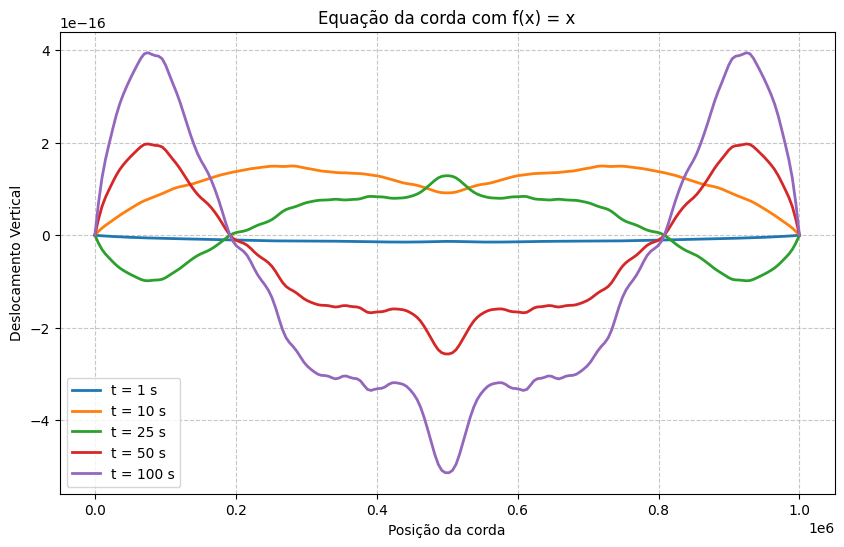

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import math

# ==========================================
# 1. Parâmetros Físicos 
# ==========================================
L = 1               # Comprimento da corda
a = math.sqrt(1)    # Velocidade de propagação da onda (m/s)
N_termos = 100      # Quantidade de termos da série de Fourier

# ==========================================
# 2. Condição Inicial g(x)
# ==========================================
def g(x):
    # Condição inicial: g(x) = x
    return x

# ==========================================
# 3. Pré-cálculo dos Coeficientes
# ==========================================
def calcula_cn(n, L):
    integrando = lambda x: g(x) * np.cos((n * np.pi * x) / L)
    integral, _ = quad(integrando, 0, L)
    return (2.0 / (n * np.pi * a)) * integral

# Pré-calculamos a integral apenas uma vez para economizar processamento
cn_values = [calcula_cn(n, L) for n in range(1, N_termos + 1)]

# ==========================================
# 4. Solução Matemática u(x,t)
# ==========================================
def eq_corda(x, t, L, a, N, coeficientes):
    soma = np.zeros_like(x)
    for n in range(1, N + 1):
        cn = coeficientes[n-1]
        termo = cn * np.sin(n * np.pi * x / L) * np.sin(n * np.pi * a * t / L)
        soma += termo
    return soma

# ==========================================
# 5. Simulação e Gráficos
# ==========================================
# 200 pontos espaciais para criar uma curva suave
x = np.linspace(0, L, 200)

# Tempos que queremos observar (em nanossegundos)
tempos = [1, 10, 25, 50, 100] 

plt.figure(figsize=(10, 6))

for t in tempos:
    equacao_corda = eq_corda(x, t, L, a, N_termos, cn_values)
    
    plt.plot(x * 1e6, equacao_corda, label=f't = {t} s', linewidth=2)

plt.title('Equação da corda com f(x) = x')
plt.xlabel(r'Posição da corda')
plt.ylabel('Deslocamento Vertical')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()